# Analiza podatkov iz knjige Orgle Slovenije

## Uvažanje potrebnih knjižnic in orodij

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from orodja.pridobivanje_podatkov import pridobi_orglarje
from orodja.zapisovanje_podatkov import zapisi_orglarje_v_csv
from orodja.filtriranje_podatkov import *

## Pridobitev in zapis podatkov

**OPOMBA:** Podrobnejši opis strukture podatkov v CSV datoteki se nahaja v datoteki [`README.md`](README.md#struktura-podatkov).

In [2]:
orglarji = pridobi_orglarje()
zapisi_orglarje_v_csv(orglarji)

org = pd.read_csv('podatki/orglarji.csv')

## Analiza

### Kako se je spreminjalo število aktivnih orglarjev na slovenskem območju

1. Aktivnost orglarjev smo gledali po desetletnih obdobjih, torej smo za določeno desetletje vzeli le tistega orglarja, ki je bil vsaj 1 leto aktiven v njem.
2. Glede na podatke pod slovenska območja štejemo:
    - LJ: Ljubljana z okolico in Gorenjska,
    - MB: Maribor in Podravje,
    - CE: Savinjska,
    - NM: Dolenjska,
    - GO: Goriška,
    - KO: Koroška.
3. Orglarja Georgius de Venetia iz leta 826 smo izpustili zaradi preglednosti grafa.
4. Število orglarjev na slovenskem območju smo na grafu primerjali s številom vseh orglarjev v knjigi.

**POMEMBNO:** Ta analiza naj nam ne bo najbolj verodostojna, saj orglarji najverjetneje niso delali samo v omenjenih območjih skozi celotno obdobje delovanja.

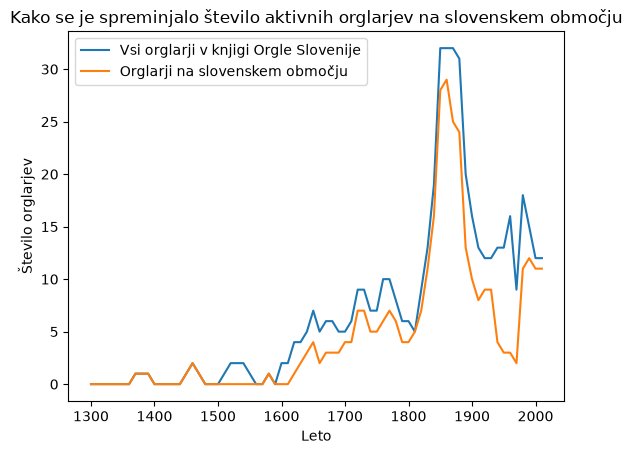

In [3]:
# Sestavimo seznam orglarjev, ki so bili aktivni v določenem desetletnem obdobju
ZACETEK, KONEC = 1300, 2020
org_v_deset = pridobi_orglarje_po_desetletjih(org, ZACETEK, KONEC)

# Pridobimo orglarje, ki so delali na slovenskem območju
SLOVENSKA_OBMOCJA = ["LJ", "MB", "CE", "NM", "GO", "KO"]
slo_org_v_deset = [pridobi_orglarje_v_obmocjih(o, SLOVENSKA_OBMOCJA) for o in org_v_deset]

# Preštejemo število orglarjev v desetletnih obdobjih
st_orglarjev = list(map(len, org_v_deset))
st_slo_orglarjev = list(map(len, slo_org_v_deset))

# Število orglarjev na slovenskem območju primerjamo na grafu s številom vseh orglarjev v knjigi
desetletja = range(ZACETEK, KONEC, 10)
plt.plot(desetletja, st_orglarjev, label="Vsi orglarji v knjigi Orgle Slovenije")
plt.plot(desetletja, st_slo_orglarjev, label="Orglarji na slovenskem območju")

# Nastavimo prikaz grafa
plt.title("Kako se je spreminjalo število aktivnih orglarjev na slovenskem območju")
plt.xlabel("Leto")
plt.ylabel("Število orglarjev")
plt.legend(loc='upper left');

Iz grafa lahko sklepamo sledeče:
- Število orglarjev na slovenskih in tujih območjih se je večinoma spreminjalo v istem toku.
- Največ orglarjev je delovalo v drugi polovici 19. stoletja.
- V času prve in druge svetovne vojne se je število orglarjev izrazito zmanjšalo.
- V času vojen je na slovenskem območju v primerjavi s sosednjimi območji orglarska obrt bolj zakrnela.

### Kako se je spreminjalo število aktivnih orglarjev po območjih

1. Aktivnost orglarjev smo ponovno gledali po desetletnih obdobjih (prav tako nismo upoštevali orglarja iz leta 826).
2. Zaradi preglednosti smo izbrali le 4 območja z največ orglarji.

**POMEMBNO:** Ta analiza naj nam ne bo najbolj verodostojna, saj orglarji najverjetneje niso delali samo v omenjenih območjih skozi celotno obdobje delovanja.

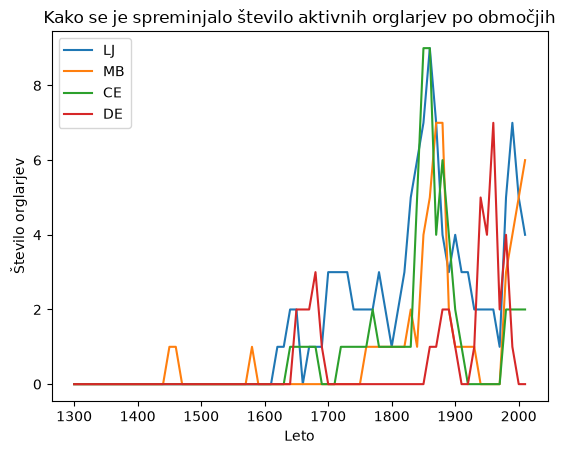

In [4]:
VSA_OBMOCJA = [
    "AT", "CE", "CZ", "DN", "NM", "GO", "GR",
    "HR", "IT", "KO", "LJ", "HU", "DE", "NL",
    "MB", "SW", "CH", "TS", "GB"
]

# Sestavimo seznam orglarjev, ki so bili aktivni v določenem območju
org_po_obm = [
    (obmocje, pridobi_orglarje_v_obmocjih(org, [obmocje])) 
    for obmocje in VSA_OBMOCJA
]

# Območja uredimo glede na število orglarjev
org_po_obm.sort(reverse=True, key=lambda x: len(x[1]))

# Vzamemo 4 območja z največ orglarji in po desetlenih obdobjih vse zapišemo v en graf
for org_obm in org_po_obm[:4]:
    org_v_deset = pridobi_orglarje_po_desetletjih(org_obm[1], ZACETEK, KONEC)
    st_org = list(map(len, org_v_deset))
    
    plt.plot(desetletja, st_org, label=org_obm[0])

# Nastavimo prikaz grafa
plt.title("Kako se je spreminjalo število aktivnih orglarjev po območjih")
plt.xlabel("Leto")
plt.ylabel("Število orglarjev")
plt.legend(loc='upper left');

Največ orglarjev je delovalo v območjih:
1. LJ: Ljubljana z okolico in Gorenjska,
2. MB: Maribor in Podravje,
3. CE: Savinjska,
4. DE: Nemčija.

Iz grafa lahko sklepamo sledeče:
- (Slovenska) območja LJ, MB in CE so se gibala v drugačnem toku kot DE.
- Ponovno lahko vidimo zakrnitev orglarske obrti na Slovenskem v času vojen (oziroma po njih), medtem ko so nemške delavnice ravno takrat najbolj aktivne na slovenskem ozemlju.
- Ob koncu 20. stoletja je orglarska obrt na slovenskem območju ponovno zaživela.
- V 21. stoletju začnejo ponovno prevladovati orglarji na slovenskem območju.

### Kako se je spreminjalo število orglarjev z domnevnim obdobjem aktivnosti

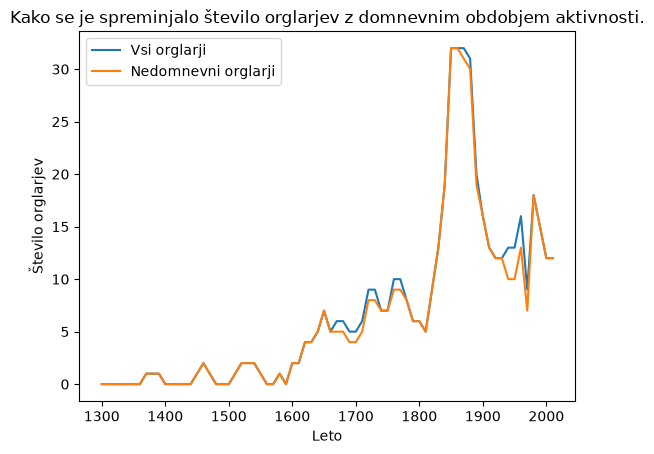

In [5]:
# Sestavimo seznam orglarjev, ki so bili aktivni v določenem desetletnem obdobju in niso domnevni
org_nedom_v_deset = pridobi_orglarje_po_desetletjih(org, ZACETEK, KONEC, glej_domnevno = False)

# Preštejemo število nedomnevnih orglarjev v desetletnih obdobjih
st_nedom_orglarjev = list(map(len, org_nedom_v_deset))

# Število vseh orglarjev primerjamo na grafu s številom vseh nedomnevnih orglarjev
plt.plot(desetletja, st_orglarjev, label="Vsi orglarji")
plt.plot(desetletja, st_nedom_orglarjev, label="Nedomnevni orglarji")

# Nastavimo prikaz grafa
plt.title("Kako se je spreminjalo število orglarjev z domnevnim obdobjem aktivnosti.")
plt.xlabel("Leto")
plt.ylabel("Število orglarjev")
plt.legend(loc='upper left');

Iz grafa lahko sklepamo sledeče:
- Orglarjev z domnevnim obdobjem je malo (6).
- V času vojen je orglarjev z domnevnim obdobjem naraslo.

Ena razlaga za narast orglarjev z domnevnim obdobjem v času vojne bi lahko bila, da so zaradi situacije uvažali orgle iz drugod in zato ni bilo vedno jasno zapisano kdaj so prišle.

### Kateri orglarji oziroma orglarske delavnice so bile najdlje aktivne

**OPOMBA:** Pod orglarske delavnice štejem orglarje, ki so imeli (stalne) sodelavce in svoje prostore za delo z orglami (izdelovanje, restavriranje ...).
Samo iz pridobljenih podatkov v resnici ne moremo vedeti kdaj govorimo o samostojnem orglarju ali o orglarski delavnici (potrebni so zunanji podatki).

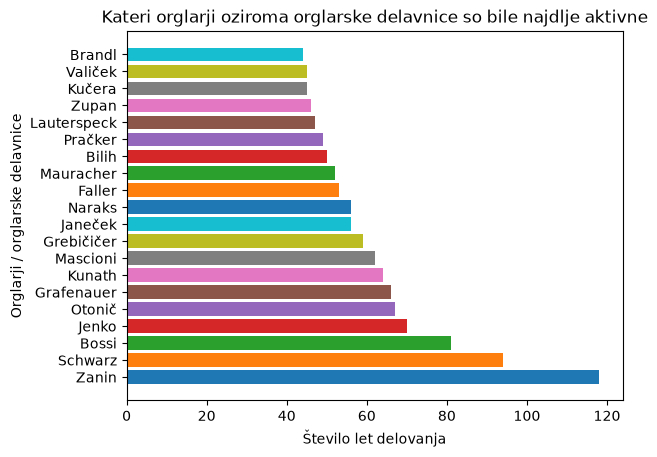

In [6]:
# Sestavimo seznam orglarjev oziroma orglarskih delavnic skupaj z njihovim časom delovanja
org_akt = [
    (naziv, konec - zacetek)
    for naziv, zacetek, konec in zip(org.kratek_naziv, org.zacetek_aktivnosti, org.konec_aktivnosti)
]

# Orglarje uredimo glede na čas aktivnosti
org_akt.sort(reverse=True, key=lambda x: x[1])

# Zapišemo 20 najdlje aktivnih orglarjev oziroma orglarskih delavnic v diagram
for naziv, cas_akt in org_akt[:20]:
    plt.barh(naziv, cas_akt)

# Nastavimo prikaz diagrama
plt.title("Kateri orglarji oziroma orglarske delavnice so bile najdlje aktivne")
plt.xlabel("Število let delovanja")
plt.ylabel("Orglarji / orglarske delavnice");

Iz diagrama lahko sklepamo sledeče:
- Najdaljše obodbje so bile aktivne orglarske delavnice in ne samostojni orglarji (glej opombo).

Vemo tudi:
- Vseh 5 najdlje aktivnih orglarskih delavnic je imelo vsaj 2 generaciji orglarjev.

### Kateri orglarji so največkrat omenjeni

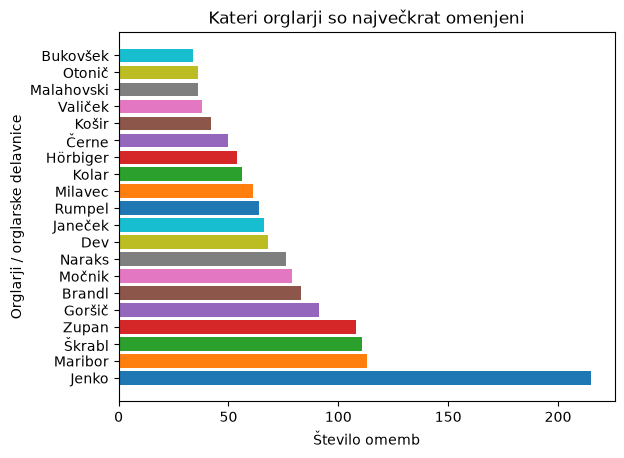

In [7]:
# Sestavimo seznam orglarjev oziroma orglarskih delavnic skupaj s številom omemb
org_om = [
    (naziv, len(eval(strani)))
    for naziv, strani in zip(org.kratek_naziv, org.strani_z_omembo)
]

# Orglarje uredimo glede na število omemb
org_om.sort(reverse=True, key=lambda x: x[1])

# Zapišemo 20 najbolj omenjenih orglarjev oziroma orglarskih delavnic v diagram
for naziv, st_om in org_om[:20]:
    plt.barh(naziv, st_om)

# Nastavimo prikaz diagrama
plt.title("Kateri orglarji so največkrat omenjeni")
plt.xlabel("Število omemb")
plt.ylabel("Orglarji / orglarske delavnice");

Iz diagrama lahko sklepamo sledeče:
- Največkrat so omenjeni slovenski orglarji.

Posledično sklepamo, da je največ opusov v knjigi iz rok slovenskih orglarjev.

### Koliko je število omemb orglarjev po straneh

**OPOMBA:** Knjiga vsebuje 678 strani.

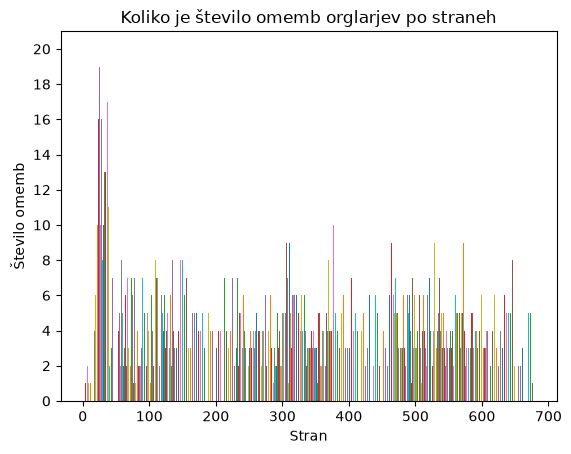

In [8]:
STEVILO_STRANI = 678

# Sestavimo seznam s številom omemb na stran
st_omemb_po_straneh = [
    (s, len(pridobi_omenjene_orglarje(org, s)))
    for s in range(1, STEVILO_STRANI + 1)
]

# Zapišemo število omemb v diagram
for stran, st_omemb in st_omemb_po_straneh:
    plt.bar(stran, st_omemb)

# Nastavimo prikaz diagrama
plt.title("Koliko je število omemb orglarjev po straneh")
plt.xlabel("Stran")
plt.ylabel("Število omemb")
plt.yticks(list(range(0, 21, 2)));


Iz diagrama lahko sklepamo sledeče:
- Največ omemb je v uvodnem delu knjige, kjer se nahaja zgodovinski pregled.
- Največ omemb ima stran 35 in to 20.
- Povprečno je v knjigi okoli 4 omemb na stran.

Zanimivi sta strani 377 in 466, kjer se nahaja kar 10 omemb različnih orglarjev.

### Povezava med številom omemb in začetkom aktivnosti

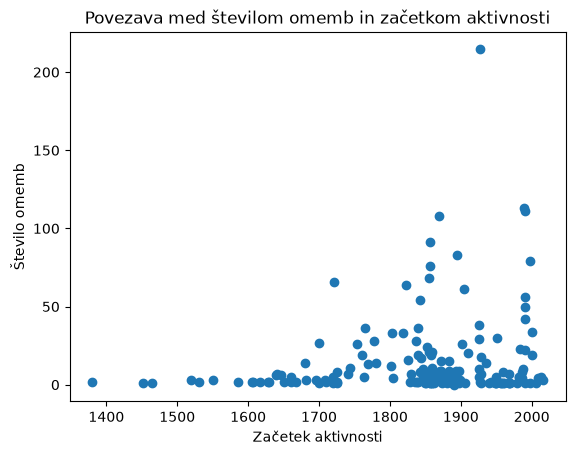

In [9]:
# Spustimo orglarje pred 1300
org_zac = org[org.zacetek_aktivnosti > 1300]

# Zapišemo podatke v graf
plt.scatter(
    org_zac.zacetek_aktivnosti,
    [len(eval(s)) for s in org_zac.strani_z_omembo],
)

# Nastavimo prikaz grafa
plt.title("Povezava med številom omemb in začetkom aktivnosti")
plt.xlabel("Začetek aktivnosti")
plt.ylabel("Število omemb");

Iz grafa raztrosa lahko sklepamo sledeče:
- Število omemb lahko povežemo z grafom o številu orglarjev za določeno desetletje:
    1. Naraščanje opomb v drugi polovici 19. stoletja.
    2. Padanje opomb v času vojen.
    3. Naraščanje opomb ob koncu 20. stoletja.

Izstopajoča točka je od orglarske delavnice Jenko.

### Kateri orglarji oziroma orglarske delavnice imajo največ drugih nazivov

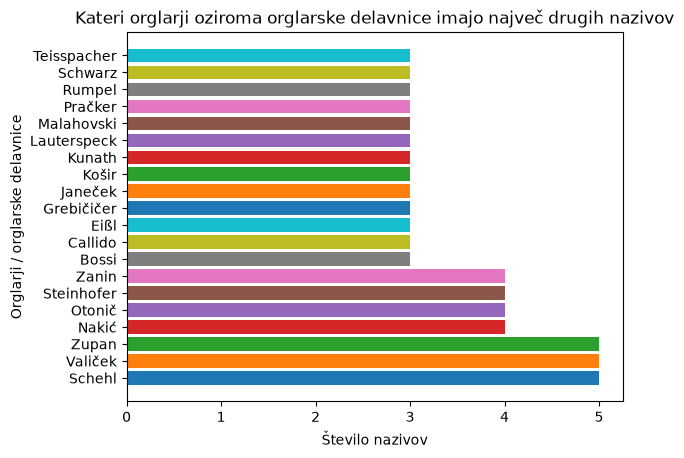

In [10]:
# Sestavimo seznam orglarjev oziroma orglarskih delavnic skupaj s številom nazivov
org_naz = [
    (naziv, len(eval(drugi_nazivi)))
    for naziv, drugi_nazivi in zip(org.kratek_naziv, org.drugi_nazivi)
]

# Orglarje uredimo glede na število nazivov
org_naz.sort(reverse=True, key=lambda x: x[1])

# Zapišemo 20 orglarjev oziroma orglarskih delavnic z največ nazivi v diagram
for naziv, st_naz in org_naz[:20]:
    plt.barh(naziv, st_naz)

# Nastavimo prikaz diagrama
plt.title("Kateri orglarji oziroma orglarske delavnice imajo največ drugih nazivov")
plt.xlabel("Število nazivov")
plt.ylabel("Orglarji / orglarske delavnice");

Iz digrama nismo izvedeli veliko (naslednja povezava pokaže, da število nazivov ni bistven podatek - vsaj za naš primer opredeljevanja drugih nazivov).

### Povezava med številom omemb in številom drugih nazivov

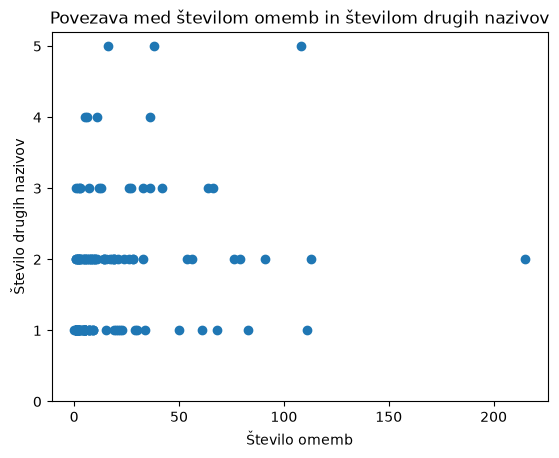

In [11]:
# Zapišemo podatke v graf
plt.scatter(
    [len(eval(s)) for s in org.strani_z_omembo],
    [len(eval(n)) for n in org.drugi_nazivi]
)

# Nastavimo prikaz grafa
plt.title("Povezava med številom omemb in številom drugih nazivov")
plt.xlabel("Število omemb")
plt.ylabel("Število drugih nazivov")
plt.yticks(list(range(0, 6)));

Iz grafa raztrosa lahko sklepamo sledeče:
- Število omemb ni povezano s številom drugih nazivov (več nazivov ni propomoglo k večjemu številu omemb).